In [1]:
import os
import matplotlib.pyplot as plt
import mplhep as hep
import uproot
import glob
import plot_utils
import numpy as np
from matplotlib import ticker
from scipy.stats import chi2

plt.rcParams['figure.dpi'] = 70
plt.style.use(hep.style.CMS)
hep.style.use("CMS")

In [3]:
limits_dir = "../cards/WH_2_6_agnostic/"
cards_dir = limits_dir + "/cards-agnostic/"
limit_files = glob.glob(limits_dir + "/*.nT*.root")
fitdiagnostics_files = glob.glob(cards_dir + "/fitDiagnostics*.root")

outDirAN = '/home/submit/{}/SUEP/AN-23-183/images/'.format(os.environ['USER'])
saveToAN = False

Read in the limits

In [3]:
limits = {}
for limit_file in limit_files:
    with uproot.open(limit_file) as f:
        data = f["limit"]["limit"].array()
    ntracks = int(limit_file.split(".root")[0].split(".nT")[-1])
    limits[ntracks] = data

In [19]:
limits

{30: <Array [2.7e+03, 3.56e+03, ... 4.38e+03] type='6 * float64'>,
 40: <Array [233, 306, 420, 577, 746, 372] type='6 * float64'>,
 50: <Array [40.6, 53.4, 73.2, 101, 132, 71.2] type='6 * float64'>,
 60: <Array [10.3, 13.6, 18.6, 25.3, 33.4, 17.1] type='6 * float64'>,
 80: <Array [0.563, 0.998, 1.92, ... 5.81, 1.92] type='6 * float64'>}

In [36]:
def plot_agnostic_limits(limits):

    fig = plt.figure(figsize=(11, 11))
    ax = fig.subplots()

    ntracks = list(limits.keys())
    xvar = np.linspace(min(ntracks),max(ntracks),1000)

    _exp = [limit[2] for limit in limits.values()]
    _s1p = [limit[1] for limit in limits.values()]
    _s1m = [limit[3] for limit in limits.values()]
    _s2p = [limit[0] for limit in limits.values()]
    _s2m = [limit[4] for limit in limits.values()]
    _obs = [limit[5] for limit in limits.values()]

    # Define interpolation
    exp_limit = plot_utils.log_interp1d(ntracks, _exp) 
    s1p_limit = plot_utils.log_interp1d(ntracks, _s1p)
    s1m_limit = plot_utils.log_interp1d(ntracks, _s1m)
    s2p_limit = plot_utils.log_interp1d(ntracks, _s2p)
    s2m_limit = plot_utils.log_interp1d(ntracks, _s2m)
    obs_limit = plot_utils.log_interp1d(ntracks, _obs)

    # Plot observed limits
    ax.scatter(ntracks, _obs, marker='o', s=70, color='#F0240Bff', label="Observed", zorder=3) 

    #Plot expected limits including brazil bands
    ax.plot(xvar, exp_limit(xvar), ls="-", ms=12, color='#F0240Bff', label="Median expected")
    ax.fill_between(xvar, s2m_limit(xvar), s2p_limit(xvar), color="#FFDF7Fff", lw=0, label="Expected 95% CL")
    ax.fill_between(xvar, s1m_limit(xvar), s1p_limit(xvar), color="#85D1FBff", lw=0, label="Expected 68% CL")
    
    # Just to make everything look nice
    ax.set_ylabel(r"Upper limit on yields at 95% CL")
    ax.set_xlabel(r"$n^{\mathrm{ak15}}_{\mathrm{constituent}}$ lower bound") 
    ax.legend(loc="upper left", fontsize=20)
    
    hep.cms.label(data=True, llabel="Preliminary", lumi=plot_utils.lumis['combined'], ax=ax) # To add CMS lumi scripts

    ax.grid(visible=True, which='major', color='grey', linestyle='--', alpha=0.3)
    ax.set_ylim(1e-1, 9e5)
    ax.set_yscale("log")

    _ = ax.text(
        0.55, 0.9,
        "anti-k$_{T}$ R=1.5 cluster of tracks\nrecoiling against a W\nwith sphericity $> 0.5$",
        fontsize=20, horizontalalignment='left', 
        verticalalignment='top', 
        transform=ax.transAxes,
    )
    
    y_major = ticker.LogLocator(base = 10.0, numticks = 20)
    ax.yaxis.set_major_locator(y_major)
    y_minor = ticker.LogLocator(base = 10.0, subs = np.arange(1.0, 10.0) * 0.1, numticks = 100)
    ax.yaxis.set_minor_locator(y_minor)
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())

    fig.tight_layout()
    fig.set_label("limits_theory_agnostic")

    return fig

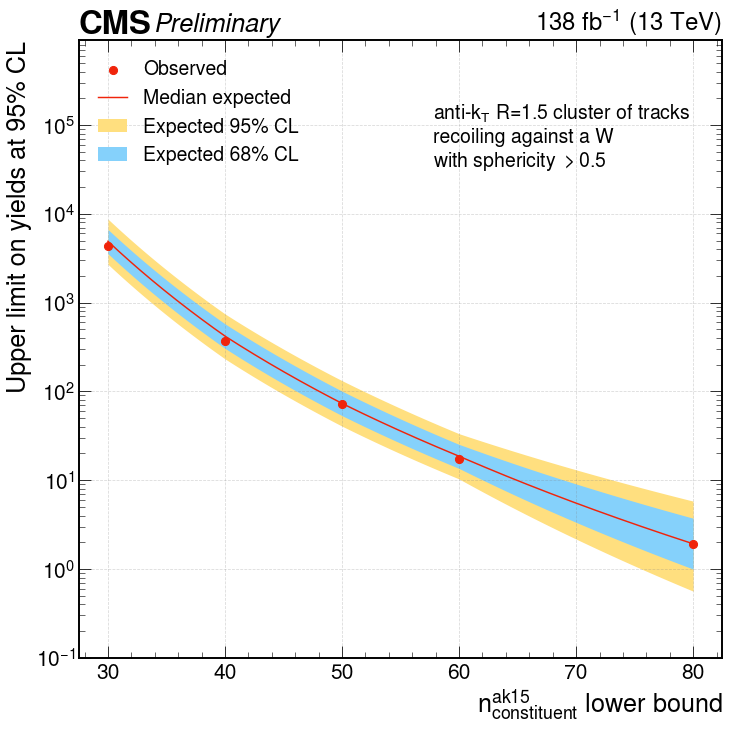

In [38]:
fig = plot_agnostic_limits(limits)

if saveToAN:
    fig.savefig(outDirAN + fig.get_label() + '.pdf', bbox_inches='tight')

Read in the FitDiagnostics outputs

In [4]:
def compute_poisson_interval(values, confidence=0.6827):
    alpha = 1 - confidence
    low = chi2.ppf(alpha / 2., 2 * values) / 2
    high = chi2.ppf(1. - alpha / 2., 2 * (values + 1)) / 2
    if np.isnan(low): low = 0
    return low, high

def read_post_fit_file(postFitFile, bins, regions):
   
    payload, payload_err = {}, {}
    for region in regions:
        
        payload[region], payload_err[region] = {}, {}

        for fit in ['fit_s', 'fit_b', 'prefit']:
                
            payload[region][fit], payload_err[region][fit] = {}, {}
            payload[region]['data'], payload_err[region]['data'] = {}, {}

            for bin in bins:

                name = 'shapes_{}/{};1'.format(fit, region+"_"+bin)

                if name not in postFitFile.keys():
                    continue
                
                payload[region][fit][bin] = postFitFile[name]['total_background;1'].values()[0]
                payload_err[region][fit][bin] = np.sqrt(postFitFile[name]['total_covar;1'].to_numpy()[0][0][0])

                payload[region]['data'][bin] = postFitFile[name]['data;1'].values()[1][0]
                payload_err[region]['data'][bin] = np.array(compute_poisson_interval(payload[region]['data'][bin]))

    return payload, payload_err

payload, payload_err = {}, {}
for fitdiagnostics_file in fitdiagnostics_files:
    print(fitdiagnostics_file)
    with uproot.open(fitdiagnostics_file) as f:
        _payload, _payload_err = read_post_fit_file(f, ["SR_SRbin0", "SR_SRbin1", "SR_SRbin2", "SR_SRbin3", "SR_SRbin4"], ['SR'])

        for fit in _payload["SR"].keys():
            if fit not in payload.keys():
                payload[fit] = _payload["SR"][fit].copy()
                payload_err[fit] = _payload_err["SR"][fit].copy()
            else:
                # update it
                payload[fit].update(_payload["SR"][fit])
                payload_err[fit].update(_payload_err["SR"][fit]) 

../cards/WH_2_6_agnostic//cards-agnostic/fitDiagnosticsnT30.root
../cards/WH_2_6_agnostic//cards-agnostic/fitDiagnosticsnT40.root
../cards/WH_2_6_agnostic//cards-agnostic/fitDiagnosticsnT50.root
../cards/WH_2_6_agnostic//cards-agnostic/fitDiagnosticsnT60.root
../cards/WH_2_6_agnostic//cards-agnostic/fitDiagnosticsnT80.root


In [87]:
table = []
table.append(
    [
        "Region",
        "$n^{\mathrm{ak15}}_{\mathrm{constituent}} > 30$",
        "$n^{\mathrm{ak15}}_{\mathrm{constituent}} > 40$",
        "$n^{\mathrm{ak15}}_{\mathrm{constituent}} > 50$",
        "$n^{\mathrm{ak15}}_{\mathrm{constituent}} > 60$",
        "$n^{\mathrm{ak15}}_{\mathrm{constituent}} > 80$"
    ]
)
table.append(
    [
        "Observed"
    ] +
    ["{:.2f}^{{+{:.2f}}}_{{-{:.2f}}}".format(payload['data'][bin], payload_err['data'][bin][1] - payload['data'][bin], payload['data'][bin]-payload_err['data'][bin][0]) for bin in payload['data'].keys()]
)
table.append(
    [
        "Pre-fit"
    ] +
    ["{:.2f} \pm {:.2f}".format(payload['prefit'][bin], payload_err['prefit'][bin]) for bin in payload['data'].keys()]
)
table.append(
    [
        "b-only fit"
    ] +
    ["{:.2f} \pm {:.2f}".format(payload['fit_b'][bin], payload_err['fit_b'][bin]) for bin in payload['data'].keys()]
)

In [88]:
# convert the table to latex
table = np.array(table)
table = np.transpose(table)
table = table.tolist()

for row in table:
    print(" & ".join(row) + " \\\\")

Region & Observed & Pre-fit & b-only fit \\
$n^{\mathrm{ak15}}_{\mathrm{constituent}} > 30$ & 60622.00^{+247.22}_{-246.22} & 61517.89 \pm 2458.86 & 60629.98 \pm 219.21 \\
$n^{\mathrm{ak15}}_{\mathrm{constituent}} > 40$ & 4402.00^{+67.35}_{-66.35} & 4486.06 \pm 179.31 & 4409.32 \pm 60.10 \\
$n^{\mathrm{ak15}}_{\mathrm{constituent}} > 50$ & 370.00^{+20.25}_{-19.23} & 373.23 \pm 14.92 & 370.80 \pm 15.29 \\
$n^{\mathrm{ak15}}_{\mathrm{constituent}} > 60$ & 29.00^{+6.45}_{-5.35} & 31.51 \pm 1.26 & 29.72 \pm 4.39 \\
$n^{\mathrm{ak15}}_{\mathrm{constituent}} > 80$ & 0.00^{+1.84}_{-0.00} & 0.00 \pm 0.00 & 0.00 \pm 0.00 \\


HEPData

In [7]:
payload

{'fit_s': {'SR_SRbin0': 60630.14,
  'SR_SRbin1': 4409.1753,
  'SR_SRbin2': 370.7611,
  'SR_SRbin3': 29.721762,
  'SR_SRbin4': 7.488823e-17},
 'data': {'SR_SRbin0': 60622.0,
  'SR_SRbin1': 4402.0,
  'SR_SRbin2': 370.0,
  'SR_SRbin3': 29.0,
  'SR_SRbin4': 0.0},
 'fit_b': {'SR_SRbin0': 60629.977,
  'SR_SRbin1': 4409.323,
  'SR_SRbin2': 370.79932,
  'SR_SRbin3': 29.721134,
  'SR_SRbin4': 7.488823e-17},
 'prefit': {'SR_SRbin0': 61517.89,
  'SR_SRbin1': 4486.058,
  'SR_SRbin2': 373.2325,
  'SR_SRbin3': 31.506863,
  'SR_SRbin4': 0.00024235863}}

In [10]:
def make_hepdata(_rpayload, _rpayload_err):

    bins = [
        'SR_SRbin0','SR_SRbin1','SR_SRbin2','SR_SRbin3','SR_SRbin4'
    ]
    bin_edges = [
        ">= 30", ">= 40", ">= 50", ">= 60", ">= 80",
    ]
    out = {}
    out['bins'] = bins
    out['bin_edges'] = bin_edges

    # post fit values for each region
    values = np.array([_rpayload['fit_b'][bin] for bin in bins])
    errors = np.array([_rpayload_err['fit_b'][bin] for bin in bins])
    values[values < 1e-5] = 0
    out['fit_b'] = values.tolist()
    out['fit_b_err'] = errors.tolist()

    # observed data for each region
    values = np.array([_rpayload['data'][b] for b in bins])
    errors = np.array([_rpayload_err['data'][bin] for bin in bins])
    errors[np.isnan(errors)] = 0
    out['data'] = values.tolist()
    out['data_err'] = np.array([values-errors[:,0], errors[:,1] - values]).T.tolist()
    
    return out

import json
hepdata = make_hepdata(payload, payload_err)

with open('Entry/hepdata_agnostic_wh.json', 'w') as f:
    json.dump(hepdata, f)

In [9]:
hepdata

{'bins': ['SR_SRbin0', 'SR_SRbin1', 'SR_SRbin2', 'SR_SRbin3', 'SR_SRbin4'],
 'bin_edges': ['>= 30', '>= 40', '>= 50', '>= 60', '>= 80'],
 'fit_b': [60629.9765625,
  4409.3232421875,
  370.79931640625,
  29.721134185791016,
  7.488822765722692e-17],
 'fit_b_err': [219.20510864257812,
  60.102508544921875,
  15.292765617370605,
  4.389235496520996,
  7.93388643671733e-09],
 'data': [60622.0, 4402.0, 370.0, 29.0, 0.0],
 'data_err': [[246.2200075238652, 247.22206750351324],
  [66.34648205459689, 67.3540504629791],
  [19.227101902126662, 20.2531593329453],
  [5.354033596749218, 6.447152584043472],
  [0.0, 1.8410547609529326]]}